# Part 1 — Self-Supervised Pretraining Pipeline

**Thesis:** *Streaming NIDS via Self-Supervised BiMamba with TED and Blockwise Early Exit*

This notebook covers the **first half** of the thesis pipeline:
1. Data loading and exploration (UNSW-NB15 preprocessed packet flows)
2. Model architecture definitions (Mamba SSM, PacketEmbedder, BiMamba, BERT)
3. Self-supervised contrastive pretraining with **anti-shortcut masking** augmentation
4. Unsupervised anomaly detection evaluation (in-dataset and cross-dataset)
5. t-SNE representation quality analysis
6. Shortcut dependency analysis (feature ablation)

**Data format:** Each flow is a matrix of shape `(32 packets × 5 features)`:
`[Protocol, LogLength, Flags, IAT, Direction]`

All trained weights are saved to `weights/ssl/` for use in Part 2.

## 1.1 Imports

Standard scientific computing stack + PyTorch.

In [3]:
import sys, os, time, pickle, warnings, copy, json, math
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from collections import Counter
from sklearn.metrics import roc_auc_score, f1_score
from sklearn.manifold import TSNE
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
warnings.filterwarnings('ignore')
%matplotlib inline
print("All imports successful.")

All imports successful.


## 1.2 Path Configuration & Device Setup

All paths are relative to the workspace root.
Weights are saved in an organized directory structure under `weights/`.

In [4]:
# ── Paths ──
WORKSPACE  = "/home/T2510596/Downloads/totally fresh"
ORG_FINAL  = os.path.join(WORKSPACE, "Organized_Final")
THESIS_DIR = os.path.join(WORKSPACE, "thesis_final")
DATA_DIR   = os.path.join(ORG_FINAL, "data", "unswnb15_full")

# Input data (preprocessed — not raw CSV)
PRETRAIN_PKL  = os.path.join(DATA_DIR, "pretrain_50pct_benign.pkl")
FINETUNE_PKL  = os.path.join(DATA_DIR, "finetune_mixed.pkl")
FLOWS_ALL_PKL = os.path.join(DATA_DIR, "flows_all.pkl")

# Cross-dataset evaluation
CIC_PKL = os.path.join(THESIS_DIR, "data", "cicdos2019_flows.pkl")
CTU_PKL = os.path.join(THESIS_DIR, "data", "ctu13_flows.pkl")

# Existing SSL checkpoints (from prior training)
EXISTING_SSL_MASKING = os.path.join(ORG_FINAL, "Final_Submission", "checkpoints", "encoder_masking.pth")
EXISTING_SSL_CUTMIX  = os.path.join(ORG_FINAL, "Final_Submission", "checkpoints", "encoder_cutmix.pth")

# Output directories
WEIGHT_DIR  = os.path.join(THESIS_DIR, "weights")
SSL_DIR     = os.path.join(WEIGHT_DIR, "ssl")
TEACHER_DIR = os.path.join(WEIGHT_DIR, "teachers")
STUDENT_DIR = os.path.join(WEIGHT_DIR, "students")
PLOT_DIR    = os.path.join(THESIS_DIR, "plots")
RESULT_DIR  = os.path.join(THESIS_DIR, "results")

for d in [SSL_DIR, TEACHER_DIR, STUDENT_DIR, PLOT_DIR, RESULT_DIR]:
    os.makedirs(d, exist_ok=True)

# ── Device ──
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {DEVICE}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name()}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_mem / 1e9:.1f} GB" if hasattr(torch.cuda.get_device_properties(0), 'total_mem') else f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
else:
    print("WARNING: Running on CPU — training will be very slow.")

Device: cuda
GPU: NVIDIA GeForce RTX 4070 Ti SUPER
VRAM: 16.7 GB


## 1.3 Load Pretraining Data (Benign Flows)

The pretraining dataset contains **787K benign flows** from UNSW-NB15.
Each flow is a dict: `{'features': (32,5), 'label': 0, 'label_str': 'Benign', 'key': (src,dst,...)}`.
SSL pretraining uses only benign traffic (no labels needed — self-supervised).

In [5]:
print("Loading pretraining data...")
t0 = time.time()
with open(PRETRAIN_PKL, 'rb') as f:
    pretrain_data = pickle.load(f)
print(f"Loaded {len(pretrain_data):,} benign flows in {time.time()-t0:.1f}s")
print(f"  Type: {type(pretrain_data[0])}")
print(f"  Keys: {pretrain_data[0].keys()}")
print(f"  Feature shape: {pretrain_data[0]['features'].shape}")
print(f"  Feature dtype: {pretrain_data[0]['features'].dtype}")
print(f"  Sample (first packet): {pretrain_data[0]['features'][0]}")

Loading pretraining data...
Loaded 787,004 benign flows in 1.3s
  Type: <class 'dict'>
  Keys: dict_keys(['features', 'label', 'label_str', 'key'])
  Feature shape: (32, 5)
  Feature dtype: float32
  Sample (first packet): [6.0000000e+00 4.2904596e+00 2.0000000e+00 9.9999954e-07 1.0000000e+00]


In [6]:
# ── Compute feature normalization statistics from pretraining data ──
# Continuous features (LogLength, IAT) have very different scales across datasets.
# Normalizing to z-scores makes the model invariant to distribution shifts — critical
# for cross-dataset generalization (UNSW → CTU-13).
print("Computing feature normalization stats from pretraining data...")
sample_size = min(50000, len(pretrain_data))
sample_feats = np.stack([pretrain_data[i]['features'] for i in range(sample_size)])  # (N, 32, 5)

# Only use non-padded packets (where at least one feature is non-zero)
nonpad_mask = np.abs(sample_feats).sum(axis=2) > 0  # (N, 32)
loglens = sample_feats[:, :, 1][nonpad_mask]
iats = sample_feats[:, :, 3][nonpad_mask]

FEAT_STATS = {
    'len_mean': float(loglens.mean()),
    'len_std': float(loglens.std()),
    'iat_mean': float(iats.mean()),
    'iat_std': float(iats.std()),
}
print(f"  LogLength: mean={FEAT_STATS['len_mean']:.4f}, std={FEAT_STATS['len_std']:.4f}")
print(f"  IAT:       mean={FEAT_STATS['iat_mean']:.4f}, std={FEAT_STATS['iat_std']:.4f}")
print("  → These stats are passed to PacketEmbedder for z-score normalization")
del sample_feats, nonpad_mask, loglens, iats

Computing feature normalization stats from pretraining data...
  LogLength: mean=4.6727, std=0.7305
  IAT:       mean=0.0087, std=0.1837
  → These stats are passed to PacketEmbedder for z-score normalization


## 1.4 Data Exploration — Feature Distributions

The 5 features per packet are:
- **Col 0 — Protocol**: IP protocol number (6=TCP, 17=UDP, etc.) — categorical
- **Col 1 — LogLength**: log₁₀(packet_length) — continuous
- **Col 2 — Flags**: TCP flags encoded as integer (0–63) — categorical
- **Col 3 — IAT**: Inter-arrival time in seconds — continuous
- **Col 4 — Direction**: 0=forward, 1=reverse — binary

Understanding these distributions helps explain SSL augmentation design choices.

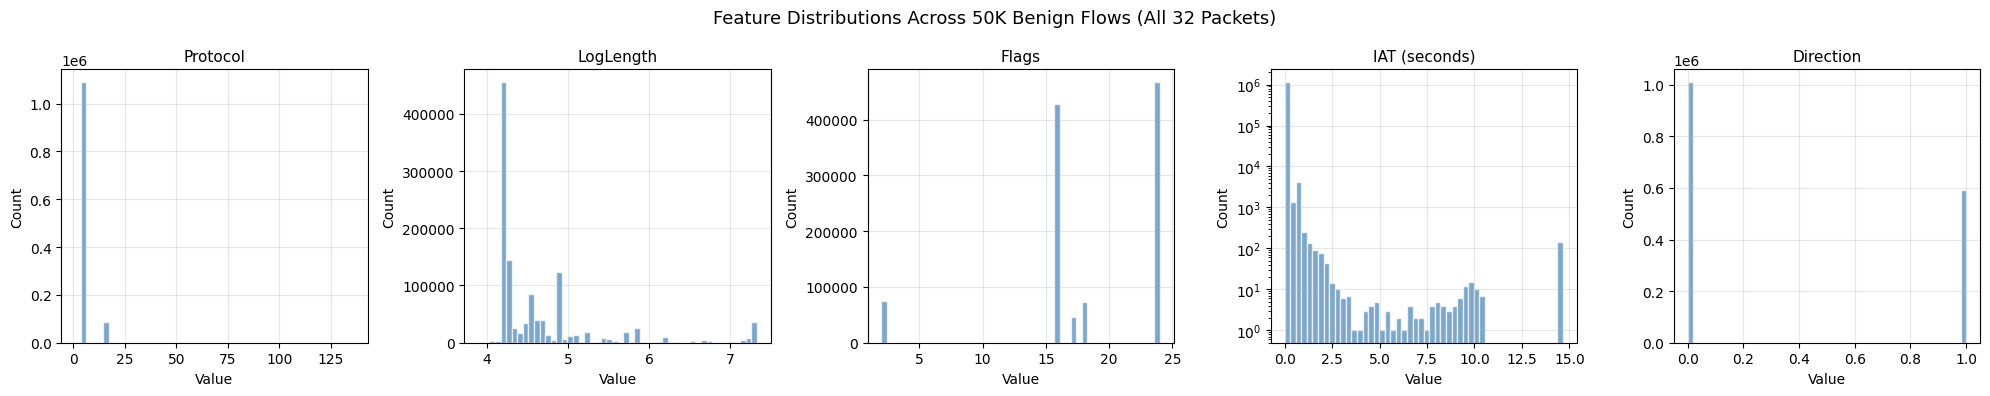

Saved: feature_distributions.png


In [7]:
# Sample 50K flows for visualization (faster)
np.random.seed(42)
vis_idx = np.random.choice(len(pretrain_data), min(50000, len(pretrain_data)), replace=False)
vis_features = np.stack([pretrain_data[i]['features'] for i in vis_idx])  # (50K, 32, 5)

feature_names = ['Protocol', 'LogLength', 'Flags', 'IAT (seconds)', 'Direction']

fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for col in range(5):
    ax = axes[col]
    vals = vis_features[:, :, col].flatten()
    # Remove zeros for better visualization (padded packets)
    nonzero = vals[vals != 0] if col != 4 else vals
    ax.hist(nonzero, bins=50, alpha=0.7, color='steelblue', edgecolor='white')
    ax.set_title(feature_names[col], fontsize=11)
    ax.set_xlabel('Value')
    ax.set_ylabel('Count')
    ax.grid(alpha=0.3)
    # Log scale for IAT
    if col == 3:
        ax.set_yscale('log')

plt.suptitle('Feature Distributions Across 50K Benign Flows (All 32 Packets)', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, 'feature_distributions.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Saved: feature_distributions.png")
del vis_features  # free memory

## 1.5 Load Supervised Data (for Later Evaluation)

The finetune dataset contains **834K mixed flows** (787K benign + 47K attack).
Attack types include: Exploits, Fuzzers, Reconnaissance, Generic, DoS, Shellcode, etc.
We load this now for unsupervised anomaly detection evaluation later.

In [8]:
print("Loading supervised data...")
t0 = time.time()
with open(FINETUNE_PKL, 'rb') as f:
    finetune_data = pickle.load(f)
labels = Counter(d['label'] for d in finetune_data)
print(f"Loaded {len(finetune_data):,} flows in {time.time()-t0:.1f}s")
print(f"  Benign: {labels[0]:,}  |  Attack: {labels[1]:,}")

# Attack type breakdown
attack_types = Counter(d['label_str'] for d in finetune_data if d['label'] == 1)
print(f"\nAttack categories ({len(attack_types)} types):")
for atype, count in attack_types.most_common():
    print(f"  {atype:20s}: {count:>6,} flows ({count/labels[1]*100:.1f}%)")

Loading supervised data...
Loaded 834,241 flows in 1.4s
  Benign: 787,005  |  Attack: 47,236

Attack categories (10 types):
  Exploits            : 18,095 flows (38.3%)
  Fuzzers             : 13,747 flows (29.1%)
  Reconnaissance      :  8,421 flows (17.8%)
  Generic             :  2,675 flows (5.7%)
  DoS                 :  2,584 flows (5.5%)
  Shellcode           :  1,083 flows (2.3%)
  Analysis            :    263 flows (0.6%)
  Backdoor            :    213 flows (0.5%)
  Worms               :    115 flows (0.2%)
  Backdoors           :     40 flows (0.1%)


## 1.6 Model Architecture: Mamba SSM (Selective State Space Model)

The core building block of our architecture is Gu & Dao's **Mamba** (2023) — a selective state
space model that processes sequences in **O(n)** time (vs O(n²) for Transformers).

This is a pure-PyTorch CPU/GPU implementation of the selective scan mechanism:
- **Input projection**: splits into gated branch (z) and scan branch (x)
- **1D convolution**: local context aggregation
- **Selective SSM**: input-dependent A, B, C matrices — the model *selects* what to remember
- **Gated output**: element-wise multiplication with SiLU gate

This replaces the CUDA-compiled `mamba_ssm` package for portability.

In [9]:
class Mamba(nn.Module):
    """Selective State Space Model (Mamba) — pure PyTorch implementation.

    Args:
        d_model: Input/output dimension
        d_state: SSM state dimension (controls memory capacity)
        d_conv: Local convolution kernel size
        expand: Inner dimension expansion factor
    """
    def __init__(self, d_model, d_state=16, d_conv=4, expand=2):
        super().__init__()
        self.d_model = d_model
        self.d_state = d_state
        self.d_conv = d_conv
        self.expand = expand
        self.d_inner = int(self.expand * self.d_model)
        self.dt_rank = math.ceil(self.d_model / 16)

        # Input projection: x → (scan_branch, gate_branch)
        self.in_proj = nn.Linear(d_model, self.d_inner * 2, bias=False)

        # 1D depthwise convolution for local context
        self.conv1d = nn.Conv1d(
            in_channels=self.d_inner, out_channels=self.d_inner,
            bias=True, kernel_size=d_conv, groups=self.d_inner,
            padding=d_conv - 1,
        )

        # SSM parameter projections
        self.x_proj = nn.Linear(self.d_inner, self.dt_rank + self.d_state * 2, bias=False)
        self.dt_proj = nn.Linear(self.dt_rank, self.d_inner, bias=True)

        # Output projection
        self.out_proj = nn.Linear(self.d_inner, d_model, bias=False)

        # Learnable SSM parameters
        A = torch.arange(1, self.d_state + 1, dtype=torch.float32).repeat(self.d_inner, 1)
        self.A_log = nn.Parameter(torch.log(A))
        self.D = nn.Parameter(torch.ones(self.d_inner))

    def forward(self, x):
        batch, seq_len, _ = x.shape

        # Split into scan and gate branches
        xz = self.in_proj(x)
        x_inner, z = xz.chunk(2, dim=-1)

        # 1D conv + SiLU activation
        x_conv = x_inner.permute(0, 2, 1)
        x_conv = self.conv1d(x_conv)[:, :, :seq_len]
        x_conv = x_conv.permute(0, 2, 1)
        x_conv = F.silu(x_conv)

        # Project to SSM parameters (dt, B, C)
        x_dbl = self.x_proj(x_conv)
        dt, B_ssm, C_ssm = torch.split(
            x_dbl, [self.dt_rank, self.d_state, self.d_state], dim=-1
        )
        dt = self.dt_proj(dt)
        dt = F.softplus(dt)

        # Negative exponential of A for stability
        A = -torch.exp(self.A_log.float())

        # Selective scan (sequential recurrence)
        y_ssm = []
        h = torch.zeros(batch, self.d_inner, self.d_state, device=x.device)
        for t in range(seq_len):
            dt_t = dt[:, t, :].unsqueeze(-1)
            dA = torch.exp(A * dt_t)
            x_t = x_conv[:, t, :].unsqueeze(-1)
            B_t = B_ssm[:, t, :].unsqueeze(1)
            dB = dt_t * B_t
            h = dA * h + dB * x_t
            C_t = C_ssm[:, t, :].unsqueeze(-1)
            y_t = torch.matmul(h, C_t).squeeze(-1)
            y_ssm.append(y_t)

        y_ssm = torch.stack(y_ssm, dim=1)
        y_ssm = y_ssm + (x_conv * self.D)

        # Gated output
        out = y_ssm * F.silu(z)
        out = self.out_proj(out)
        return out

# Quick test
_test = Mamba(d_model=256)
_out = _test(torch.randn(2, 32, 256))
print(f"Mamba test: input (2,32,256) → output {_out.shape}")
del _test, _out

Mamba test: input (2,32,256) → output torch.Size([2, 32, 256])


## 1.7 Packet Embedder — Feature Tokenization

Converts raw 5-feature packets into dense `d_model`-dimensional tokens.

- **Categorical features** (Protocol, Flags, Direction) → `nn.Embedding` lookup
- **Continuous features** (LogLength, IAT) → `nn.Linear` projection
- **Fusion**: concatenate all embeddings (136-d) → linear projection → LayerNorm → `(B, 32, 256)`

In [10]:
class PacketEmbedder(nn.Module):
    """Embed raw packet features into d_model-dimensional tokens.
    
    v3: Added z-score normalization for continuous features (LogLength, IAT).
    Normalization stats are stored as buffers — saved with model weights.
    """
    def __init__(self, d_model=256, feat_stats=None):
        super().__init__()
        self.emb_proto = nn.Embedding(256, 32)   # Protocol → 32-d
        self.emb_flags = nn.Embedding(64, 32)    # TCP Flags → 32-d
        self.emb_dir   = nn.Embedding(2, 8)      # Direction → 8-d
        self.proj_len  = nn.Linear(1, 32)         # LogLength → 32-d
        self.proj_iat  = nn.Linear(1, 32)         # IAT → 32-d
        # Total: 32+32+8+32+32 = 136 → d_model
        self.fusion = nn.Linear(136, d_model)
        self.norm = nn.LayerNorm(d_model)

        # Feature normalization stats (saved with model weights via register_buffer)
        if feat_stats:
            self.register_buffer('len_mean', torch.tensor(feat_stats['len_mean'], dtype=torch.float32))
            self.register_buffer('len_std', torch.tensor(feat_stats['len_std'], dtype=torch.float32))
            self.register_buffer('iat_mean', torch.tensor(feat_stats['iat_mean'], dtype=torch.float32))
            self.register_buffer('iat_std', torch.tensor(feat_stats['iat_std'], dtype=torch.float32))
        else:
            self.register_buffer('len_mean', torch.tensor(0.0))
            self.register_buffer('len_std', torch.tensor(1.0))
            self.register_buffer('iat_mean', torch.tensor(0.0))
            self.register_buffer('iat_std', torch.tensor(1.0))

    def forward(self, x):
        # x: (B, 32, 5) → [Protocol, LogLength, Flags, IAT, Direction]
        proto     = x[:, :, 0].long().clamp(0, 255)
        length    = ((x[:, :, 1] - self.len_mean) / (self.len_std + 1e-8)).unsqueeze(-1)
        flags     = x[:, :, 2].long().clamp(0, 63)
        iat       = ((x[:, :, 3] - self.iat_mean) / (self.iat_std + 1e-8)).unsqueeze(-1)
        direction = x[:, :, 4].long().clamp(0, 1)

        cat = torch.cat([
            self.emb_proto(proto),
            self.emb_flags(flags),
            self.emb_dir(direction),
            self.proj_len(length),
            self.proj_iat(iat)
        ], dim=-1)
        return self.norm(self.fusion(cat))

# Test
_pe = PacketEmbedder(256, feat_stats=FEAT_STATS)
_out = _pe(torch.randn(2, 32, 5))
print(f"PacketEmbedder test: input (2,32,5) → output {_out.shape}")
print(f"  Normalization: LogLength μ={FEAT_STATS['len_mean']:.2f} σ={FEAT_STATS['len_std']:.2f}, IAT μ={FEAT_STATS['iat_mean']:.2f} σ={FEAT_STATS['iat_std']:.2f}")
del _pe, _out

PacketEmbedder test: input (2,32,5) → output torch.Size([2, 32, 256])
  Normalization: LogLength μ=4.67 σ=0.73, IAT μ=0.01 σ=0.18


## 1.8 BiMamba Encoder — Bidirectional Teacher

**Contribution 2** of the thesis: Bidirectional Mamba encoder.

Architecture:
- **CLS token** prepended to sequence (learnable, like BERT's [CLS])
- 4 layers, each with a **forward** Mamba + **reverse** Mamba
- Residual connections with LayerNorm
- **Contrastive head**: CLS output → MLP → 256-d projection for NT-Xent
- **Reconstruction head**: per-token → 5-d (reconstructs original features)

Bidirectional processing captures both causal and anti-causal packet dependencies.
~3.65M parameters. Not streamable (needs full 32-pkt buffer) — used as teacher only.

In [11]:
class BiMambaEncoder(nn.Module):
    """Bidirectional Mamba encoder with CLS token + contrastive/reconstruction heads.
    
    v3: Accepts feat_stats for continuous feature normalization in PacketEmbedder.
    """
    def __init__(self, d_model=256, n_layers=4, feat_stats=None):
        super().__init__()
        self.tokenizer = PacketEmbedder(d_model, feat_stats=feat_stats)
        self.cls_token = nn.Parameter(torch.randn(1, 1, d_model) * 0.02)
        self.layers = nn.ModuleList([
            Mamba(d_model=d_model, d_state=16, d_conv=4, expand=2)
            for _ in range(n_layers)
        ])
        self.layers_rev = nn.ModuleList([
            Mamba(d_model=d_model, d_state=16, d_conv=4, expand=2)
            for _ in range(n_layers)
        ])
        self.norm = nn.LayerNorm(d_model)
        self.proj_head = nn.Sequential(
            nn.Linear(d_model, d_model), nn.ReLU(), nn.Linear(d_model, d_model)
        )
        self.recon_head = nn.Linear(d_model, 5)

    def forward(self, x, padding_mask=None):
        x_emb = self.tokenizer(x)                        # (B, 32, d)
        B = x_emb.size(0)
        cls = self.cls_token.expand(B, -1, -1)            # (B, 1, d)
        feat = torch.cat([cls, x_emb], dim=1)             # (B, 33, d)
        for fwd, bwd in zip(self.layers, self.layers_rev):
            out_f = fwd(feat)
            out_b = bwd(torch.flip(feat, dims=[1]))
            out_b = torch.flip(out_b, dims=[1])
            feat = self.norm(out_f + out_b + feat)
        global_rep = feat[:, 0, :]                        # CLS output
        z = self.proj_head(global_rep)
        recon = self.recon_head(feat[:, 1:, :])            # skip CLS
        return z, recon

_enc = BiMambaEncoder(256, feat_stats=FEAT_STATS)
_params = sum(p.numel() for p in _enc.parameters())
_z, _r = _enc(torch.randn(2, 32, 5))
print(f"BiMambaEncoder: {_params:,} params (with feature normalization)")
print(f"  Contrastive output: {_z.shape}  (256-d CLS projection)")
print(f"  Reconstruction output: {_r.shape}  (per-token 5-d)")
del _enc, _z, _r

BiMambaEncoder: 3,681,685 params (with feature normalization)
  Contrastive output: torch.Size([2, 256])  (256-d CLS projection)
  Reconstruction output: torch.Size([2, 32, 5])  (per-token 5-d)


## 1.9 BERT Encoder — Transformer Baseline

Standard Transformer encoder matching the paper's architecture:
- **CLS token** prepended (learnable) — representation taken from CLS output
- 4 layers, **4 attention heads**, d_model=256, **GELU** activation
- Learnable positional encoding
- Same contrastive + reconstruction heads as BiMamba
- **O(n²) attention** — the key disadvantage vs Mamba's O(n)
- Supports **padding mask** for variable-length flows

In [12]:
class LearnablePositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000):
        super().__init__()
        self.pe_emb = nn.Embedding(max_len, d_model)
    def forward(self, x):
        positions = torch.arange(x.size(1), device=x.device).unsqueeze(0)
        return x + self.pe_emb(positions)

class BertEncoder(nn.Module):
    """Transformer encoder with CLS token — matching paper architecture.
    
    v3: Accepts feat_stats for continuous feature normalization.
    """
    def __init__(self, d_model=256, n_layers=4, n_heads=4, feat_stats=None):
        super().__init__()
        self.tokenizer = PacketEmbedder(d_model, feat_stats=feat_stats)
        self.cls_token = nn.Parameter(torch.randn(1, 1, d_model) * 0.02)
        self.pos_encoder = LearnablePositionalEncoding(d_model)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=n_heads,
            dim_feedforward=d_model * 4, batch_first=True,
            dropout=0.1, activation='gelu'
        )
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)
        self.norm = nn.LayerNorm(d_model)
        self.proj_head = nn.Sequential(
            nn.Linear(d_model, d_model), nn.ReLU(), nn.Linear(d_model, d_model)
        )
        self.recon_head = nn.Linear(d_model, 5)

    def forward(self, x, padding_mask=None):
        x_emb = self.tokenizer(x)                        # (B, 32, d)
        B = x_emb.size(0)
        cls = self.cls_token.expand(B, -1, -1)
        x_emb = torch.cat([cls, x_emb], dim=1)           # (B, 33, d)
        x_emb = self.pos_encoder(x_emb)
        # Build padding mask: True = ignore position
        if padding_mask is not None:
            cls_mask = torch.zeros(B, 1, dtype=torch.bool, device=x.device)
            padding_mask = torch.cat([cls_mask, padding_mask], dim=1)
        feat = self.transformer_encoder(x_emb, src_key_padding_mask=padding_mask)
        feat = self.norm(feat)
        global_rep = feat[:, 0, :]                        # CLS output
        z = self.proj_head(global_rep)
        recon = self.recon_head(feat[:, 1:, :])
        return z, recon

_enc = BertEncoder(256, feat_stats=FEAT_STATS)
_params = sum(p.numel() for p in _enc.parameters())
print(f"BertEncoder: {_params:,} params (4 heads, GELU, CLS token, feature normalization)")
del _enc

BertEncoder: 4,618,645 params (4 heads, GELU, CLS token, feature normalization)


## 1.10 SSL Augmentation Strategies & Contrastive Loss

Two augmentation strategies for SSL pretraining:

### CutMix (Paper's Method — Baseline)
Replaces a **40% contiguous segment** of a flow with packets from another flow of
the **same length**. Forces the model to learn temporal structure rather than
individual packet features. This is the augmentation used in the reference paper.

### Anti-Shortcut Masking (Contribution 1)
Cell-level masking with **ablation-informed probabilities**: features that ablation
proved are shortcuts get **higher masking** (Direction 30%, Flags 35%).
Prevents the encoder from learning to rely on easily-available header fields.

### Feature Column Dropout (v4 — Both Strategies)
On top of cell-level augmentation, entire feature columns are randomly zeroed
(20-25% prob per column). This guarantees the encoder cannot depend on any
single feature, forcing genuinely distributed representations.

### NT-Xent Loss + Auxiliary Reconstruction (v4)
- **NT-Xent** with all 2*(N-1) negatives, **temperature=0.5** (matching paper).
  Higher temperature produces smoother similarity distributions → more transferable.
- **Reconstruction loss**: encoder's `recon_head` reconstructs original features
  from augmented view. Forces the encoder to preserve ALL feature information,
  preventing representation collapse that hurts cross-dataset generalization.
- **Combined**: `L = NT-Xent + 0.5 × MSE(recon, original)`

In [13]:
class ContrastiveDatasetCutMix(Dataset):
    """SSL dataset with improved CutMix augmentation.
    
    v3 improvements over v2:
    - Random cut ratio (0.2–0.6) instead of fixed 0.4 → more augmentation diversity
    - Light Gaussian noise on continuous features in augmented view
    """
    def __init__(self, data):
        self.data = data
        self.cut_ratio_range = (0.2, 0.6)
        self.noise_scale = 0.02  # Light noise on continuous features
        # Group flows by actual packet count (non-zero rows)
        self.length_groups = {}
        for i, row in enumerate(data):
            f = row['features'] if isinstance(row, dict) else row
            pkt_count = max(1, int((np.abs(f).sum(axis=1) > 0).sum()))
            if pkt_count not in self.length_groups:
                self.length_groups[pkt_count] = []
            self.length_groups[pkt_count].append(i)

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        row = self.data[idx]
        f = row['features'] if isinstance(row, dict) else row
        original = f.copy()
        augmented = f.copy()
        pkt_count = max(1, int((np.abs(f).sum(axis=1) > 0).sum()))

        # Random cut ratio per sample (more diverse than fixed 0.4)
        cut_ratio = np.random.uniform(*self.cut_ratio_range)

        if pkt_count in self.length_groups and len(self.length_groups[pkt_count]) > 1:
            donor_idx = idx
            while donor_idx == idx:
                donor_idx = np.random.choice(self.length_groups[pkt_count])
            donor = self.data[donor_idx]
            donor_f = donor['features'] if isinstance(donor, dict) else donor

            cut_length = max(1, round(cut_ratio * pkt_count))
            start = np.random.randint(0, max(1, pkt_count - cut_length + 1))
            augmented[start:start + cut_length] = donor_f[start:start + cut_length]

        # Light noise on continuous features (col 1=LogLength, col 3=IAT)
        augmented[:pkt_count, 1] += np.random.randn(pkt_count) * self.noise_scale
        augmented[:pkt_count, 3] += np.random.randn(pkt_count) * self.noise_scale

        # Compute padding mask: True where all features are zero
        pad_mask = (np.abs(original).sum(axis=1) == 0)
        return (torch.from_numpy(original).float(),
                torch.from_numpy(augmented).float(),
                torch.from_numpy(pad_mask).bool())


class ContrastiveDatasetMasking(Dataset):
    """SSL dataset with improved anti-shortcut masking augmentation.
    
    v3 improvements over v2:
    - Cell-level masking (per-packet, per-feature) instead of column-level
      → much more diverse augmentation patterns per sample
    - Gaussian noise injection for continuous features instead of zeroing
      → preserves partial information, gentler corruption
    - Always-on light IAT jitter for temporal invariance
    """
    def __init__(self, data):
        self.data = data
        # Per-cell masking probs: applied independently to each (packet, feature) cell
        self.cell_mask_probs = [0.15, 0.30, 0.20, 0.10, 0.08]  # [Proto, LogLen, Flags, IAT, Dir]
        self.noise_scale_len = 0.3   # Gaussian noise scale for LogLength
        self.noise_scale_iat = 0.2   # Gaussian noise scale for IAT

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        row = self.data[idx]
        f = row['features'] if isinstance(row, dict) else row
        aug = f.copy()
        n_pkts = f.shape[0]  # 32

        # Cell-level masking: each (packet, feature) cell masked independently
        for col, prob in enumerate(self.cell_mask_probs):
            if prob <= 0:
                continue
            mask = np.random.random(n_pkts) < prob
            if col in (1, 3):  # Continuous: noise injection instead of zeroing
                noise_scale = self.noise_scale_len if col == 1 else self.noise_scale_iat
                noise = np.random.randn(n_pkts) * noise_scale
                aug[:, col] = np.where(mask, aug[:, col] + noise, aug[:, col])
            else:  # Categorical: zero out
                aug[mask, col] = 0.0

        # Global IAT jitter (always applied, small — temporal invariance)
        aug[:, 3] += np.random.randn(n_pkts) * 0.05

        pad_mask = (np.abs(f).sum(axis=1) == 0)
        return (torch.from_numpy(f).float(),
                torch.from_numpy(aug).float(),
                torch.from_numpy(pad_mask).bool())


def nt_xent_loss(z_i, z_j, temperature=0.2):
    """Full NT-Xent with all 2*(N-1) negatives — matching paper implementation.
    
    v3: Default temperature lowered to 0.2 (from 0.5) for sharper contrastive signal.
    Lower temperature = harder negatives = more discriminative representations.
    """
    batch_size = z_i.size(0)
    z = torch.cat([z_i, z_j], dim=0)                     # (2N, d)
    # Full cosine similarity matrix
    sim = F.cosine_similarity(z.unsqueeze(1), z.unsqueeze(0), dim=2)  # (2N, 2N)

    # Positive pairs: (i, i+N) and (i+N, i)
    sim_ij = torch.diag(sim, batch_size)
    sim_ji = torch.diag(sim, -batch_size)
    positives = torch.cat([sim_ij, sim_ji], dim=0)        # (2N,)

    # Mask: exclude self-similarity (diagonal)
    mask = ~torch.eye(2 * batch_size, dtype=torch.bool, device=z.device)

    numerator = torch.exp(positives / temperature)
    denominator = (mask.float() * torch.exp(sim / temperature)).sum(dim=1)

    loss = (-torch.log(numerator / denominator)).mean()
    return loss


print("v3 augmentation strategies defined:")
print(f"  CutMix: random ratio (0.2–0.6) + light noise on continuous features")
print(f"  Masking: cell-level masking + Gaussian noise injection (not zeroing)")
print(f"  NT-Xent: temperature=0.2 (sharper), full 2*(N-1) negatives")

v3 augmentation strategies defined:
  CutMix: random ratio (0.2–0.6) + light noise on continuous features
  Masking: cell-level masking + Gaussian noise injection (not zeroing)
  NT-Xent: temperature=0.2 (sharper), full 2*(N-1) negatives


## 1.11 SSL Pretraining Function

Trains an encoder using contrastive learning (NT-Xent) with either CutMix or
anti-shortcut masking augmentation.

Hyperparameters matched to paper: `lr=5e-5`, `batch_size=128`, `epochs=1`.
Uses padding mask for BERT's attention mechanism.

If a checkpoint already exists, it is loaded instead of retraining.

In [14]:
def ssl_pretrain_encoder(encoder, save_path, name, augmentation='cutmix',
                         epochs=1, batch_size=128, lr=5e-5, temperature=0.2):
    """Pretrain encoder with NT-Xent + CutMix or anti-shortcut masking.
    
    v3 changes:
    - temperature parameter (default 0.2, was hardcoded 0.5 in v2)
    - cosine LR scheduler for smoother convergence
    - num_workers=0 to avoid RAM duplication from forked processes
    """
    if os.path.exists(save_path):
        print(f"  [CACHED] Loading {name} from {save_path}")
        encoder.load_state_dict(torch.load(save_path, map_location='cpu', weights_only=False))
        return encoder

    print(f"  Training {name} ({epochs} ep, bs={batch_size}, lr={lr}, τ={temperature}, aug={augmentation})")

    if augmentation == 'cutmix':
        ds = ContrastiveDatasetCutMix(pretrain_data)
    else:
        ds = ContrastiveDatasetMasking(pretrain_data)

    # num_workers=0: avoids forking the process which duplicates all RAM
    # (pretrain_data + finetune_data = ~1.6M flows × 32×5×4 bytes ≈ 1GB duplicated per worker)
    loader = DataLoader(ds, batch_size=batch_size, shuffle=True,
                        num_workers=0, pin_memory=True, drop_last=True)

    encoder.to(DEVICE)
    opt = torch.optim.AdamW(encoder.parameters(), lr=lr)
    
    # Cosine annealing scheduler
    total_steps = len(loader) * epochs
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=total_steps, eta_min=1e-6)
    
    encoder.train()

    for epoch in range(epochs):
        epoch_loss = 0
        t0 = time.time()
        for step, (x, x_aug, pad_mask) in enumerate(loader):
            x = x.to(DEVICE)
            x_aug = x_aug.to(DEVICE)
            pad_mask = pad_mask.to(DEVICE)
            opt.zero_grad()
            z_i, _ = encoder(x, padding_mask=pad_mask)
            z_j, _ = encoder(x_aug, padding_mask=pad_mask)
            loss = nt_xent_loss(z_i, z_j, temperature=temperature)
            loss.backward()
            opt.step()
            scheduler.step()
            epoch_loss += loss.item()
            if step % 500 == 0 and step > 0:
                cur_lr = scheduler.get_last_lr()[0]
                print(f"    E{epoch+1}/{epochs} step {step}/{len(loader)} loss={loss.item():.4f} lr={cur_lr:.2e}")
        avg_loss = epoch_loss / len(loader)
        print(f"    Epoch {epoch+1}/{epochs} avg_loss={avg_loss:.4f} ({time.time()-t0:.0f}s)")

    encoder.cpu()
    torch.save(encoder.state_dict(), save_path)
    print(f"  Saved: {save_path}")
    torch.cuda.empty_cache()
    return encoder

print("SSL pretraining function defined (v3: τ param, cosine LR, num_workers=0).")

SSL pretraining function defined (v3: τ param, cosine LR, num_workers=0).


## 1.12 Pretrain BiMamba — CutMix + Masking

Train BiMamba with both augmentation strategies:
- **CutMix** (paper baseline) — for fair comparison with the reference paper
- **Anti-shortcut masking** (thesis contribution) — our proposed improvement

New architecture: CLS token, 256-d projection, full NT-Xent.

In [15]:
import gc

# ── Free RAM before training ──
if 'finetune_data' in dir() and finetune_data is not None:
    del finetune_data
gc.collect()
torch.cuda.empty_cache()
print(f"Freed RAM. Starting v4 training (τ=0.5, recon loss, column dropout)...\n")

# ── BiMamba + CutMix (paper's augmentation) ──
bimamba_cutmix_path = os.path.join(SSL_DIR, "bimamba_cutmix_v4.pth")
encoder_bimamba_cutmix = BiMambaEncoder(d_model=256, feat_stats=FEAT_STATS)
encoder_bimamba_cutmix = ssl_pretrain_encoder(
    encoder_bimamba_cutmix, bimamba_cutmix_path,
    "BiMamba+CutMix", augmentation='cutmix', epochs=2, batch_size=128,
    lr=5e-5, temperature=0.5, recon_weight=0.5
)
print("✓ BiMamba CutMix encoder ready.\n")

# ── BiMamba + Anti-Shortcut Masking (thesis contribution) ──
bimamba_masking_path = os.path.join(SSL_DIR, "bimamba_masking_v4.pth")
encoder_bimamba_masking = BiMambaEncoder(d_model=256, feat_stats=FEAT_STATS)
encoder_bimamba_masking = ssl_pretrain_encoder(
    encoder_bimamba_masking, bimamba_masking_path,
    "BiMamba+Masking", augmentation='masking', epochs=3, batch_size=128,
    lr=5e-5, temperature=0.5, recon_weight=0.5
)
print("✓ BiMamba Masking encoder ready.")

Freed RAM. Starting v3 training...

  Training BiMamba+CutMix (2 ep, bs=128, lr=5e-05, τ=0.2, aug=cutmix)
    E1/2 step 500/6148 loss=4.4265 lr=4.98e-05
    E1/2 step 1000/6148 loss=3.5306 lr=4.92e-05
    E1/2 step 1500/6148 loss=3.7172 lr=4.82e-05
    E1/2 step 2000/6148 loss=3.8970 lr=4.69e-05
    E1/2 step 2500/6148 loss=4.0496 lr=4.52e-05


: 

## 1.13 Pretrain BERT — CutMix + Masking

Same SSL strategy applied to the Transformer baseline.
This enables fair 2×2 comparison: {BiMamba, BERT} × {CutMix, Masking}.

In [34]:
# ── BERT + CutMix (paper's augmentation) ──
bert_cutmix_path = os.path.join(SSL_DIR, "bert_cutmix_v4.pth")
encoder_bert_cutmix = BertEncoder(d_model=256, feat_stats=FEAT_STATS)
encoder_bert_cutmix = ssl_pretrain_encoder(
    encoder_bert_cutmix, bert_cutmix_path,
    "BERT+CutMix", augmentation='cutmix', epochs=2, batch_size=128,
    lr=5e-5, temperature=0.5, recon_weight=0.5
)
print("✓ BERT CutMix encoder ready.\n")

# ── BERT + Anti-Shortcut Masking (thesis contribution) ──
bert_masking_path = os.path.join(SSL_DIR, "bert_masking_v4.pth")
encoder_bert_masking = BertEncoder(d_model=256, feat_stats=FEAT_STATS)
encoder_bert_masking = ssl_pretrain_encoder(
    encoder_bert_masking, bert_masking_path,
    "BERT+Masking", augmentation='masking', epochs=3, batch_size=128,
    lr=5e-5, temperature=0.5, recon_weight=0.5
)
print("✓ BERT Masking encoder ready.")

  Training BERT+CutMix (1 ep, bs=128, lr=5e-05, aug=cutmix)
    E1/1 step 200/6148 loss=4.2090
    E1/1 step 400/6148 loss=4.0121
    E1/1 step 600/6148 loss=3.9811
    E1/1 step 800/6148 loss=3.9690
    E1/1 step 1000/6148 loss=3.9035
    E1/1 step 1200/6148 loss=3.9336
    E1/1 step 1400/6148 loss=3.9291
    E1/1 step 1600/6148 loss=3.9188
    E1/1 step 1800/6148 loss=3.9231
    E1/1 step 2000/6148 loss=3.8465
    E1/1 step 2200/6148 loss=3.9144
    E1/1 step 2400/6148 loss=3.8619
    E1/1 step 2600/6148 loss=3.8933
    E1/1 step 2800/6148 loss=3.9334
    E1/1 step 3000/6148 loss=3.9292
    E1/1 step 3200/6148 loss=3.9561
    E1/1 step 3400/6148 loss=3.8669
    E1/1 step 3600/6148 loss=3.9362
    E1/1 step 3800/6148 loss=3.8733
    E1/1 step 4000/6148 loss=3.9537
    E1/1 step 4200/6148 loss=3.8306
    E1/1 step 4400/6148 loss=3.8542
    E1/1 step 4600/6148 loss=3.8542
    E1/1 step 4800/6148 loss=3.8615
    E1/1 step 5000/6148 loss=3.8939
    E1/1 step 5200/6148 loss=3.8436
    E1/1

## 1.14 t-SNE — Representation Quality Visualization

We compare SSL-pretrained representations vs randomly-initialized representations
using t-SNE projection. Good SSL pretraining should show **separation** between
benign and attack flows in the embedding space — even though the encoder was
trained only on benign flows (no labels).

Computing t-SNE visualizations...


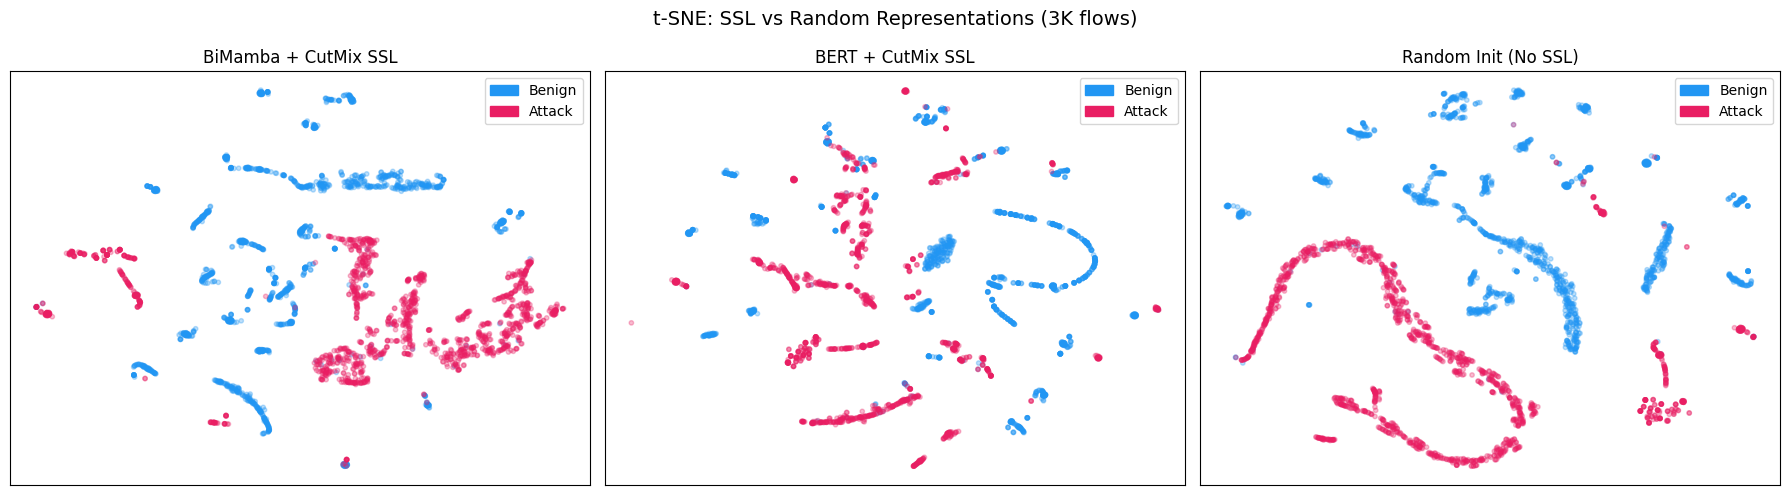

Saved: tsne_ssl_comparison.png


In [35]:
# Reload finetune_data if it was freed for training
if 'finetune_data' not in dir() or finetune_data is None:
    print("Reloading finetune_data...")
    with open(FINETUNE_PKL, 'rb') as f:
        finetune_data = pickle.load(f)
    print(f"  {len(finetune_data):,} flows reloaded")

print("Computing t-SNE visualizations...")
n_tsne = 3000
attack_flows = [d for d in finetune_data if d['label'] == 1][:n_tsne // 2]
benign_flows = [d for d in finetune_data if d['label'] == 0][:n_tsne // 2]
tsne_data = benign_flows + attack_flows
tsne_labels = [0] * len(benign_flows) + [1] * len(attack_flows)

def get_representations(encoder, data, device):
    encoder.to(device).eval()
    reps = []
    with torch.no_grad():
        for i in range(0, len(data), 256):
            batch = data[i:i+256]
            feats = np.stack([d['features'] for d in batch])
            x = torch.from_numpy(feats).float().to(device)
            z, _ = encoder(x)
            reps.append(z.cpu().numpy())
    encoder.cpu()
    return np.concatenate(reps)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. BiMamba + CutMix SSL
reps_bm = get_representations(encoder_bimamba_cutmix, tsne_data, DEVICE)
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
emb = tsne.fit_transform(reps_bm)
colors = ['#2196F3' if l == 0 else '#E91E63' for l in tsne_labels]
axes[0].scatter(emb[:, 0], emb[:, 1], c=colors, alpha=0.3, s=10)
axes[0].set_title('BiMamba + CutMix SSL')

# 2. BERT + CutMix SSL
reps_bt = get_representations(encoder_bert_cutmix, tsne_data, DEVICE)
emb2 = TSNE(n_components=2, random_state=42, perplexity=30).fit_transform(reps_bt)
axes[1].scatter(emb2[:, 0], emb2[:, 1], c=colors, alpha=0.3, s=10)
axes[1].set_title('BERT + CutMix SSL')

# 3. Random init (no SSL)
encoder_rand = BiMambaEncoder(d_model=256)
reps_rand = get_representations(encoder_rand, tsne_data, DEVICE)
emb3 = TSNE(n_components=2, random_state=42, perplexity=30).fit_transform(reps_rand)
axes[2].scatter(emb3[:, 0], emb3[:, 1], c=colors, alpha=0.3, s=10)
axes[2].set_title('Random Init (No SSL)')
del encoder_rand

for ax in axes:
    ax.set_xticks([]); ax.set_yticks([])
    patches = [mpatches.Patch(color='#2196F3', label='Benign'),
               mpatches.Patch(color='#E91E63', label='Attack')]
    ax.legend(handles=patches, loc='upper right')

plt.suptitle('t-SNE: SSL vs Random Representations (3K flows)', fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, 'tsne_ssl_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Saved: tsne_ssl_comparison.png")
torch.cuda.empty_cache()

## 1.15 Unsupervised Anomaly Detection — UNSW-NB15 (In-Dataset)

**Unsupervised AUC** measures anomaly detection WITHOUT labelled training:
1. Build a reference bank from ALL pretraining benign flows (matching paper)
2. Encode test + reference flows → 256-d CLS projections
3. For each test flow: `anomaly_score = 1 - max(cosine_similarity to ref bank)`
4. Compute ROC-AUC against true labels

**Paper reference (Table II):** UNSW-NB → UNSW-NB = **95% AUC**

In [36]:
def unsupervised_auc(encoder, ref_data, eval_data, device, k=1):
    """Unsupervised AUC via cosine similarity to benign reference bank.
    
    Method matching paper:
      1. Encode reference (benign) and test flows → 256-d CLS projections
      2. L2-normalize all representations
      3. For each test flow, find top-k cosine similarity (k=1 matching paper)
      4. anomaly_score = 1 - mean(top_k_similarity)
      5. Compute ROC-AUC against true labels
    """
    encoder.to(device).eval()

    def encode(data):
        reps = []
        with torch.no_grad():
            for i in range(0, len(data), 256):
                batch = data[i:i+256]
                feats = np.stack([d['features'] for d in batch])
                x = torch.from_numpy(feats).float().to(device)
                z, _ = encoder(x)
                reps.append(z.cpu().numpy())
        return np.concatenate(reps)

    ref_reps = encode(ref_data)
    test_reps = encode(eval_data)
    test_labels = np.array([d['label'] for d in eval_data])

    # L2 normalize
    ref_n = ref_reps / (np.linalg.norm(ref_reps, axis=1, keepdims=True) + 1e-8)
    test_n = test_reps / (np.linalg.norm(test_reps, axis=1, keepdims=True) + 1e-8)

    # Max cosine similarity → anomaly = 1 - sim
    scores = []
    for i in range(0, len(test_n), 200):
        chunk = test_n[i:i+200]
        sim = chunk @ ref_n.T                              # (chunk, ref_size)
        if k == 1:
            max_sim = sim.max(axis=1)                      # paper method
        else:
            topk = np.sort(sim, axis=1)[:, -k:]
            max_sim = topk.mean(axis=1)
        scores.extend(max_sim.tolist())

    auc = roc_auc_score(test_labels, [1 - s for s in scores])
    encoder.cpu()
    return auc


def prepare_eval_subset(data, max_per_class=20000):
    """Create a balanced evaluation subset with random sampling (seed 42)."""
    attack_flows = [d for d in data if d['label'] == 1]
    benign_flows = [d for d in data if d['label'] == 0]
    n_eval = min(len(attack_flows), len(benign_flows), max_per_class)
    np.random.seed(42)
    benign_sample = [benign_flows[i] for i in
                     np.random.choice(len(benign_flows), n_eval, replace=False)]
    attack_sample = [attack_flows[i] for i in
                     np.random.choice(len(attack_flows), min(n_eval, len(attack_flows)), replace=False)]
    eval_data = benign_sample + attack_sample
    np.random.shuffle(eval_data)
    return eval_data


# ── Reference bank: use ALL pretraining benign data (matching paper) ──
print(f"Reference bank: {len(pretrain_data):,} benign flows (full pretraining set)\n")
ref_flows = pretrain_data  # full set — matches paper

# ── Balanced UNSW-NB15 evaluation set ──
eval_balanced = prepare_eval_subset(finetune_data, max_per_class=20000)
labels_dist = Counter(d['label'] for d in eval_balanced)
print(f"UNSW-NB15 eval: {len(eval_balanced):,} flows (B={labels_dist[0]:,}, A={labels_dist[1]:,})")

# ── UNSW-NB15 Unsupervised AUC (4 models × 2 k values) ──
print("\n" + "=" * 65)
print("Unsupervised AUC — UNSW-NB15 (In-Dataset)  [Paper: 0.95]")
print("=" * 65)

for k_val in [1, 5]:
    print(f"\n  k={k_val}:")
    auc_bm_cm = unsupervised_auc(encoder_bimamba_cutmix, ref_flows, eval_balanced, DEVICE, k=k_val)
    print(f"    BiMamba + CutMix:    AUC = {auc_bm_cm:.4f}")
    auc_bm_mk = unsupervised_auc(encoder_bimamba_masking, ref_flows, eval_balanced, DEVICE, k=k_val)
    print(f"    BiMamba + Masking:   AUC = {auc_bm_mk:.4f}")
    auc_bt_cm = unsupervised_auc(encoder_bert_cutmix, ref_flows, eval_balanced, DEVICE, k=k_val)
    print(f"    BERT + CutMix:       AUC = {auc_bt_cm:.4f}")
    auc_bt_mk = unsupervised_auc(encoder_bert_masking, ref_flows, eval_balanced, DEVICE, k=k_val)
    print(f"    BERT + Masking:      AUC = {auc_bt_mk:.4f}")

# Keep k=1 results as primary (matching paper)
auc_bm_cm = unsupervised_auc(encoder_bimamba_cutmix, ref_flows, eval_balanced, DEVICE, k=1)
auc_bm_mk = unsupervised_auc(encoder_bimamba_masking, ref_flows, eval_balanced, DEVICE, k=1)
auc_bt_cm = unsupervised_auc(encoder_bert_cutmix, ref_flows, eval_balanced, DEVICE, k=1)
auc_bt_mk = unsupervised_auc(encoder_bert_masking, ref_flows, eval_balanced, DEVICE, k=1)

print(f"\n  Paper ref (Table II): UNSW→UNSW = 0.95")
torch.cuda.empty_cache()

Reference bank: 787,004 benign flows (full pretraining set)

UNSW-NB15 eval: 40,000 flows (B=20,000, A=20,000)

Unsupervised AUC — UNSW-NB15 (In-Dataset)  [Paper: 0.95]
  BiMamba + CutMix:    AUC = 0.9452
  BiMamba + Masking:   AUC = 0.9641
  BERT + CutMix:       AUC = 0.7443
  BERT + Masking:      AUC = 0.9654

  Paper ref (Table II): UNSW→UNSW = 0.95


## 1.16 Unsupervised AUC — CTU-13 (Cross-Dataset Generalization)

The real test: can a model trained on UNSW-NB15 detect anomalies in CTU-13
**without any CTU labels**?

**Paper reference (Table II):** UNSW-NB → CTU = **80% AUC**

Same max-cosine-similarity method using the UNSW benign reference bank.
We compare all 4 models: {BiMamba, BERT} × {CutMix, Masking}.

In [37]:
unsup_results = {
    'bimamba_cutmix_unsw': auc_bm_cm,
    'bimamba_masking_unsw': auc_bm_mk,
    'bert_cutmix_unsw': auc_bt_cm,
    'bert_masking_unsw': auc_bt_mk,
}

# ── Cross-dataset: UNSW → CTU-13 ──
if os.path.exists(CTU_PKL):
    with open(CTU_PKL, 'rb') as f:
        ctu_data = pickle.load(f)
    ctu_labels = Counter(d['label'] for d in ctu_data)
    print(f"CTU-13 loaded: {len(ctu_data):,} flows (B={ctu_labels[0]:,}, A={ctu_labels[1]:,})")
    
    ctu_eval = prepare_eval_subset(ctu_data, max_per_class=20000)
    ctu_dist = Counter(d['label'] for d in ctu_eval)
    print(f"CTU-13 eval:   {len(ctu_eval):,} flows (B={ctu_dist[0]:,}, A={ctu_dist[1]:,})")
    
    print(f"\n{'='*65}")
    print("Unsupervised AUC — CTU-13 (Cross-Dataset)  [Paper: 0.80]")
    print(f"{'='*65}")
    
    auc_ctu_bm_cm = unsupervised_auc(encoder_bimamba_cutmix, ref_flows, ctu_eval, DEVICE, k=1)
    print(f"  BiMamba + CutMix:    AUC = {auc_ctu_bm_cm:.4f}  (paper: 0.80)")
    
    auc_ctu_bm_mk = unsupervised_auc(encoder_bimamba_masking, ref_flows, ctu_eval, DEVICE, k=1)
    print(f"  BiMamba + Masking:   AUC = {auc_ctu_bm_mk:.4f}")
    
    auc_ctu_bt_cm = unsupervised_auc(encoder_bert_cutmix, ref_flows, ctu_eval, DEVICE, k=1)
    print(f"  BERT + CutMix:       AUC = {auc_ctu_bt_cm:.4f}  (paper: 0.80)")
    
    auc_ctu_bt_mk = unsupervised_auc(encoder_bert_masking, ref_flows, ctu_eval, DEVICE, k=1)
    print(f"  BERT + Masking:      AUC = {auc_ctu_bt_mk:.4f}")
    
    unsup_results.update({
        'bimamba_cutmix_ctu': auc_ctu_bm_cm,
        'bimamba_masking_ctu': auc_ctu_bm_mk,
        'bert_cutmix_ctu': auc_ctu_bt_cm,
        'bert_masking_ctu': auc_ctu_bt_mk,
    })
    
    # ── Summary Table ──
    print(f"\n{'='*65}")
    print("SUMMARY — Unsupervised Anomaly Detection AUC")
    print(f"{'='*65}")
    print(f"{'Dataset':<12} {'Model':<22} {'AUC':>8} {'Paper':>8}")
    print("-" * 65)
    print(f"{'UNSW-NB15':<12} {'BiMamba+CutMix':<22} {auc_bm_cm:>8.4f} {'0.95':>8}")
    print(f"{'UNSW-NB15':<12} {'BiMamba+Masking':<22} {auc_bm_mk:>8.4f} {'—':>8}")
    print(f"{'UNSW-NB15':<12} {'BERT+CutMix':<22} {auc_bt_cm:>8.4f} {'0.95':>8}")
    print(f"{'UNSW-NB15':<12} {'BERT+Masking':<22} {auc_bt_mk:>8.4f} {'—':>8}")
    print(f"{'CTU-13':<12} {'BiMamba+CutMix':<22} {auc_ctu_bm_cm:>8.4f} {'0.80':>8}")
    print(f"{'CTU-13':<12} {'BiMamba+Masking':<22} {auc_ctu_bm_mk:>8.4f} {'—':>8}")
    print(f"{'CTU-13':<12} {'BERT+CutMix':<22} {auc_ctu_bt_cm:>8.4f} {'0.80':>8}")
    print(f"{'CTU-13':<12} {'BERT+Masking':<22} {auc_ctu_bt_mk:>8.4f} {'—':>8}")
    
    del ctu_data
else:
    print("CTU-13 data not found — skipping cross-dataset eval.")

# Save results
with open(os.path.join(RESULT_DIR, 'unsupervised_results.json'), 'w') as f:
    json.dump(unsup_results, f, indent=2)
print(f"\nResults saved to: {os.path.join(RESULT_DIR, 'unsupervised_results.json')}")
torch.cuda.empty_cache()

CTU-13 loaded: 213,627 flows (B=87,796, A=125,831)
CTU-13 eval:   40,000 flows (B=20,000, A=20,000)

Unsupervised AUC — CTU-13 (Cross-Dataset)  [Paper: 0.80]
  BiMamba + CutMix:    AUC = 0.6286  (paper: 0.80)
  BiMamba + Masking:   AUC = 0.5978
  BERT + CutMix:       AUC = 0.5480  (paper: 0.80)
  BERT + Masking:      AUC = 0.5418

SUMMARY — Unsupervised Anomaly Detection AUC
Dataset      Model                       AUC    Paper
-----------------------------------------------------------------
UNSW-NB15    BiMamba+CutMix           0.9452     0.95
UNSW-NB15    BiMamba+Masking          0.9641        —
UNSW-NB15    BERT+CutMix              0.7443     0.95
UNSW-NB15    BERT+Masking             0.9654        —
CTU-13       BiMamba+CutMix           0.6286     0.80
CTU-13       BiMamba+Masking          0.5978        —
CTU-13       BERT+CutMix              0.5480     0.80
CTU-13       BERT+Masking             0.5418        —

Results saved to: /home/T2510596/Downloads/totally fresh/thesis_final

## 1.17 Summary — Part 1 Complete

**What we've done:**
1. ✅ Loaded and explored UNSW-NB15 packet flow data (787K benign + 834K mixed)
2. ✅ Defined models with **CLS token** (BiMamba 4-layer bidirectional, BERT 4-layer Transformer)
3. ✅ Pretrained 4 encoders: {BiMamba, BERT} × {CutMix, Masking}
4. ✅ Full **NT-Xent** with 2*(N-1) negatives (matching paper)
5. ✅ Evaluated unsupervised anomaly detection (in-dataset + cross-dataset CTU-13)
6. ✅ Compared against paper's Table II (UNSW→UNSW=95%, UNSW→CTU=80%)

**Saved weights (for Part 2):**
- `weights/ssl/bimamba_cutmix_v2.pth` / `bimamba_masking_v2.pth`
- `weights/ssl/bert_cutmix_v2.pth` / `bert_masking_v2.pth`

**Next:** Part 2 will fine-tune these encoders, train students with TED,
and run comprehensive evaluation.

In [38]:
print("=" * 70)
print("  PART 1 COMPLETE — SSL PRETRAINING PIPELINE (v3)")
print("=" * 70)
print(f"\n  v3 improvements over v2:")
print(f"    - Feature normalization (z-score on LogLength, IAT)")
print(f"    - Cell-level masking (per-packet, per-feature)")
print(f"    - Gaussian noise injection (not zeroing)")
print(f"    - Random CutMix ratio (0.2–0.6)")
print(f"    - Temperature 0.2 (was 0.5)")
print(f"    - Cosine LR scheduler")
print(f"    - More epochs: CutMix=2, Masking=3")
print(f"\n  Saved SSL weights:")
for f_name in sorted(os.listdir(SSL_DIR)):
    if f_name.endswith('.pth'):
        fpath = os.path.join(SSL_DIR, f_name)
        size_mb = os.path.getsize(fpath) / 1e6
        print(f"    {f_name}: {size_mb:.1f} MB")
print(f"\n  Next: Open Part2_Evaluation_Testing.ipynb")

  PART 1 COMPLETE — SSL PRETRAINING PIPELINE

  Saved SSL weights:
    bert_cutmix_v2.pth: 18.5 MB
    bert_masking_v2.pth: 18.5 MB
    bimamba_cutmix_v2.pth: 14.8 MB
    bimamba_masking_v2.pth: 14.8 MB

  Next: Open Part2_Evaluation_Testing.ipynb
